# 🚀 Missão Aurora Siger — Relatório Operacional de Pré-Decolagem

**Disciplina integradora:** Ciência da Computação, Pensamento Computacional (Python), IA & Prompt Engineering, Energias Renováveis e Sustentáveis, Formação Social e Sustentabilidade

**Objetivo:** consolidar as verificações técnicas, energéticas e éticas necessárias para autorizar (ou abortar) a decolagem da nave **Aurora Siger**.

Este notebook está organizado exatamente segundo os itens da atividade integradora:

1. [1.1 Organização e descrição da telemetria](#1.1)
2. [1.2 Algoritmo de verificação](#1.2)
3. [1.3 Script em Python](#1.3)
4. [1.4 Análise energética](#1.4)
5. [1.5 Análise assistida por IA](#1.5)
6. [1.6 Reflexão crítica](#1.6)


<a id="1.1"></a>
## 1.1 Organização e descrição da telemetria

A tabela abaixo descreve cada parâmetro monitorado pelos sensores da nave durante a janela de pré-decolagem, sua unidade e a **faixa segura predefinida** que será usada pelo algoritmo de verificação (item 1.2):

| Parâmetro | Unidade | Faixa segura | Descrição |
|---|---|---|---|
| Temperatura interna | °C | 18 a 27 | Temperatura da cabine/eletrônica embarcada; fora dessa faixa há risco térmico para sistemas e tripulação |
| Temperatura externa | °C | -60 a 45 | Temperatura do casco/ambiente externo, monitorada para avaliar estresse térmico estrutural |
| Integridade estrutural | booleano (0/1) | deve ser 1 | Sensor que indica se o casco e as junções estruturais estão íntegros (1) ou comprometidos (0) |
| Nível de energia | % | mínimo 40% | Carga atual da bateria principal em relação à capacidade total |
| Pressão dos tanques (oxidante/combustível) | bar | 150 a 200 | Pressurização dos propelentes; fora da faixa indica risco de falha de queima ou de sobrepressão |
| Status dos módulos críticos | booleano por módulo (0/1) | todos = 1 | Navegação, comunicação, propulsão, suporte de vida e aviônica — cada um deve reportar operacional (1) |

Abaixo, os dados são carregados como um dicionário estruturado (`telemetria`), simulando a leitura recebida dos sensores da nave. Dois cenários são simulados para validar o algoritmo em ambas as direções: um **nominal** (todos os parâmetros na faixa segura) e um **com falhas** (para comprovar que o sistema aborta corretamente a decolagem).

In [1]:
# Faixas seguras predefinidas (parâmetros de engenharia da missão)
FAIXAS_SEGURAS = {
    "temperatura_interna_c": (18.0, 27.0),
    "temperatura_externa_c": (-60.0, 45.0),
    "nivel_energia_pct": (40, 100),
    "pressao_tanque_bar": (150.0, 200.0),
}

MODULOS_CRITICOS_ESPERADOS = [
    "navegacao", "comunicacao", "propulsao", "suporte_vida", "avionica"
]

FAIXAS_SEGURAS

{'temperatura_interna_c': (18.0, 27.0),
 'temperatura_externa_c': (-60.0, 45.0),
 'nivel_energia_pct': (40, 100),
 'pressao_tanque_bar': (150.0, 200.0)}

In [2]:
def gerar_telemetria_nominal():
    """Cenário GO: todos os parâmetros dentro da faixa segura."""
    return {
        "timestamp": "T-00:10:00",
        "temperatura_interna_c": 21.5,
        "temperatura_externa_c": -42.3,
        "integridade_estrutural": 1,
        "nivel_energia_pct": 87,
        "pressao_tanque_oxidante_bar": 182.0,
        "pressao_tanque_combustivel_bar": 178.5,
        "modulos_criticos": {
            "navegacao": 1, "comunicacao": 1, "propulsao": 1,
            "suporte_vida": 1, "avionica": 1,
        },
    }

def gerar_telemetria_com_falha():
    """Cenário NO-GO: simula anomalias para validar o ramo de abort do algoritmo."""
    return {
        "timestamp": "T-00:10:00",
        "temperatura_interna_c": 29.8,             # fora da faixa segura
        "temperatura_externa_c": -41.0,
        "integridade_estrutural": 1,
        "nivel_energia_pct": 33,                   # abaixo do mínimo
        "pressao_tanque_oxidante_bar": 182.0,
        "pressao_tanque_combustivel_bar": 141.0,   # abaixo do mínimo
        "modulos_criticos": {
            "navegacao": 1, "comunicacao": 1, "propulsao": 0,  # falha
            "suporte_vida": 1, "avionica": 1,
        },
    }

import pandas as pd
telemetria_nominal = gerar_telemetria_nominal()
pd.Series(telemetria_nominal)

timestamp                                                                T-00:10:00
temperatura_interna_c                                                          21.5
temperatura_externa_c                                                         -42.3
integridade_estrutural                                                            1
nivel_energia_pct                                                                87
pressao_tanque_oxidante_bar                                                   182.0
pressao_tanque_combustivel_bar                                                178.5
modulos_criticos                  {'navegacao': 1, 'comunicacao': 1, 'propulsao'...
dtype: object

<a id="1.2"></a>
## 1.2 Algoritmo de verificação

**Pseudocódigo:**

```
INÍCIO
LER temperatura_interna, temperatura_externa, integridade_estrutural,
    nivel_energia, pressao_tanque_oxidante, pressao_tanque_combustivel,
    modulos_criticos[]

falhas <- lista vazia

SE temperatura_interna NÃO ESTÁ ENTRE 18 E 27 ENTÃO
    ADICIONAR falha "temperatura interna fora da faixa"

SE temperatura_externa NÃO ESTÁ ENTRE -60 E 45 ENTÃO
    ADICIONAR falha "temperatura externa fora da faixa"

SE integridade_estrutural != 1 ENTÃO
    ADICIONAR falha "integridade estrutural comprometida"

SE nivel_energia < 40 ENTÃO
    ADICIONAR falha "energia insuficiente"

PARA CADA tanque EM [oxidante, combustivel]
    SE pressao(tanque) NÃO ESTÁ ENTRE 150 E 200 ENTÃO
        ADICIONAR falha "pressão do tanque fora da faixa"

PARA CADA modulo EM modulos_criticos
    SE modulo != 1 ENTÃO
        ADICIONAR falha "módulo crítico com falha: " + nome_modulo

SE falhas está vazia ENTÃO
    status <- "PRONTO PARA DECOLAR"
SENÃO
    status <- "DECOLAGEM ABORTADA"

IMPRIMIR status
IMPRIMIR falhas (se houver)
FIM
```

**Fluxograma equivalente:**


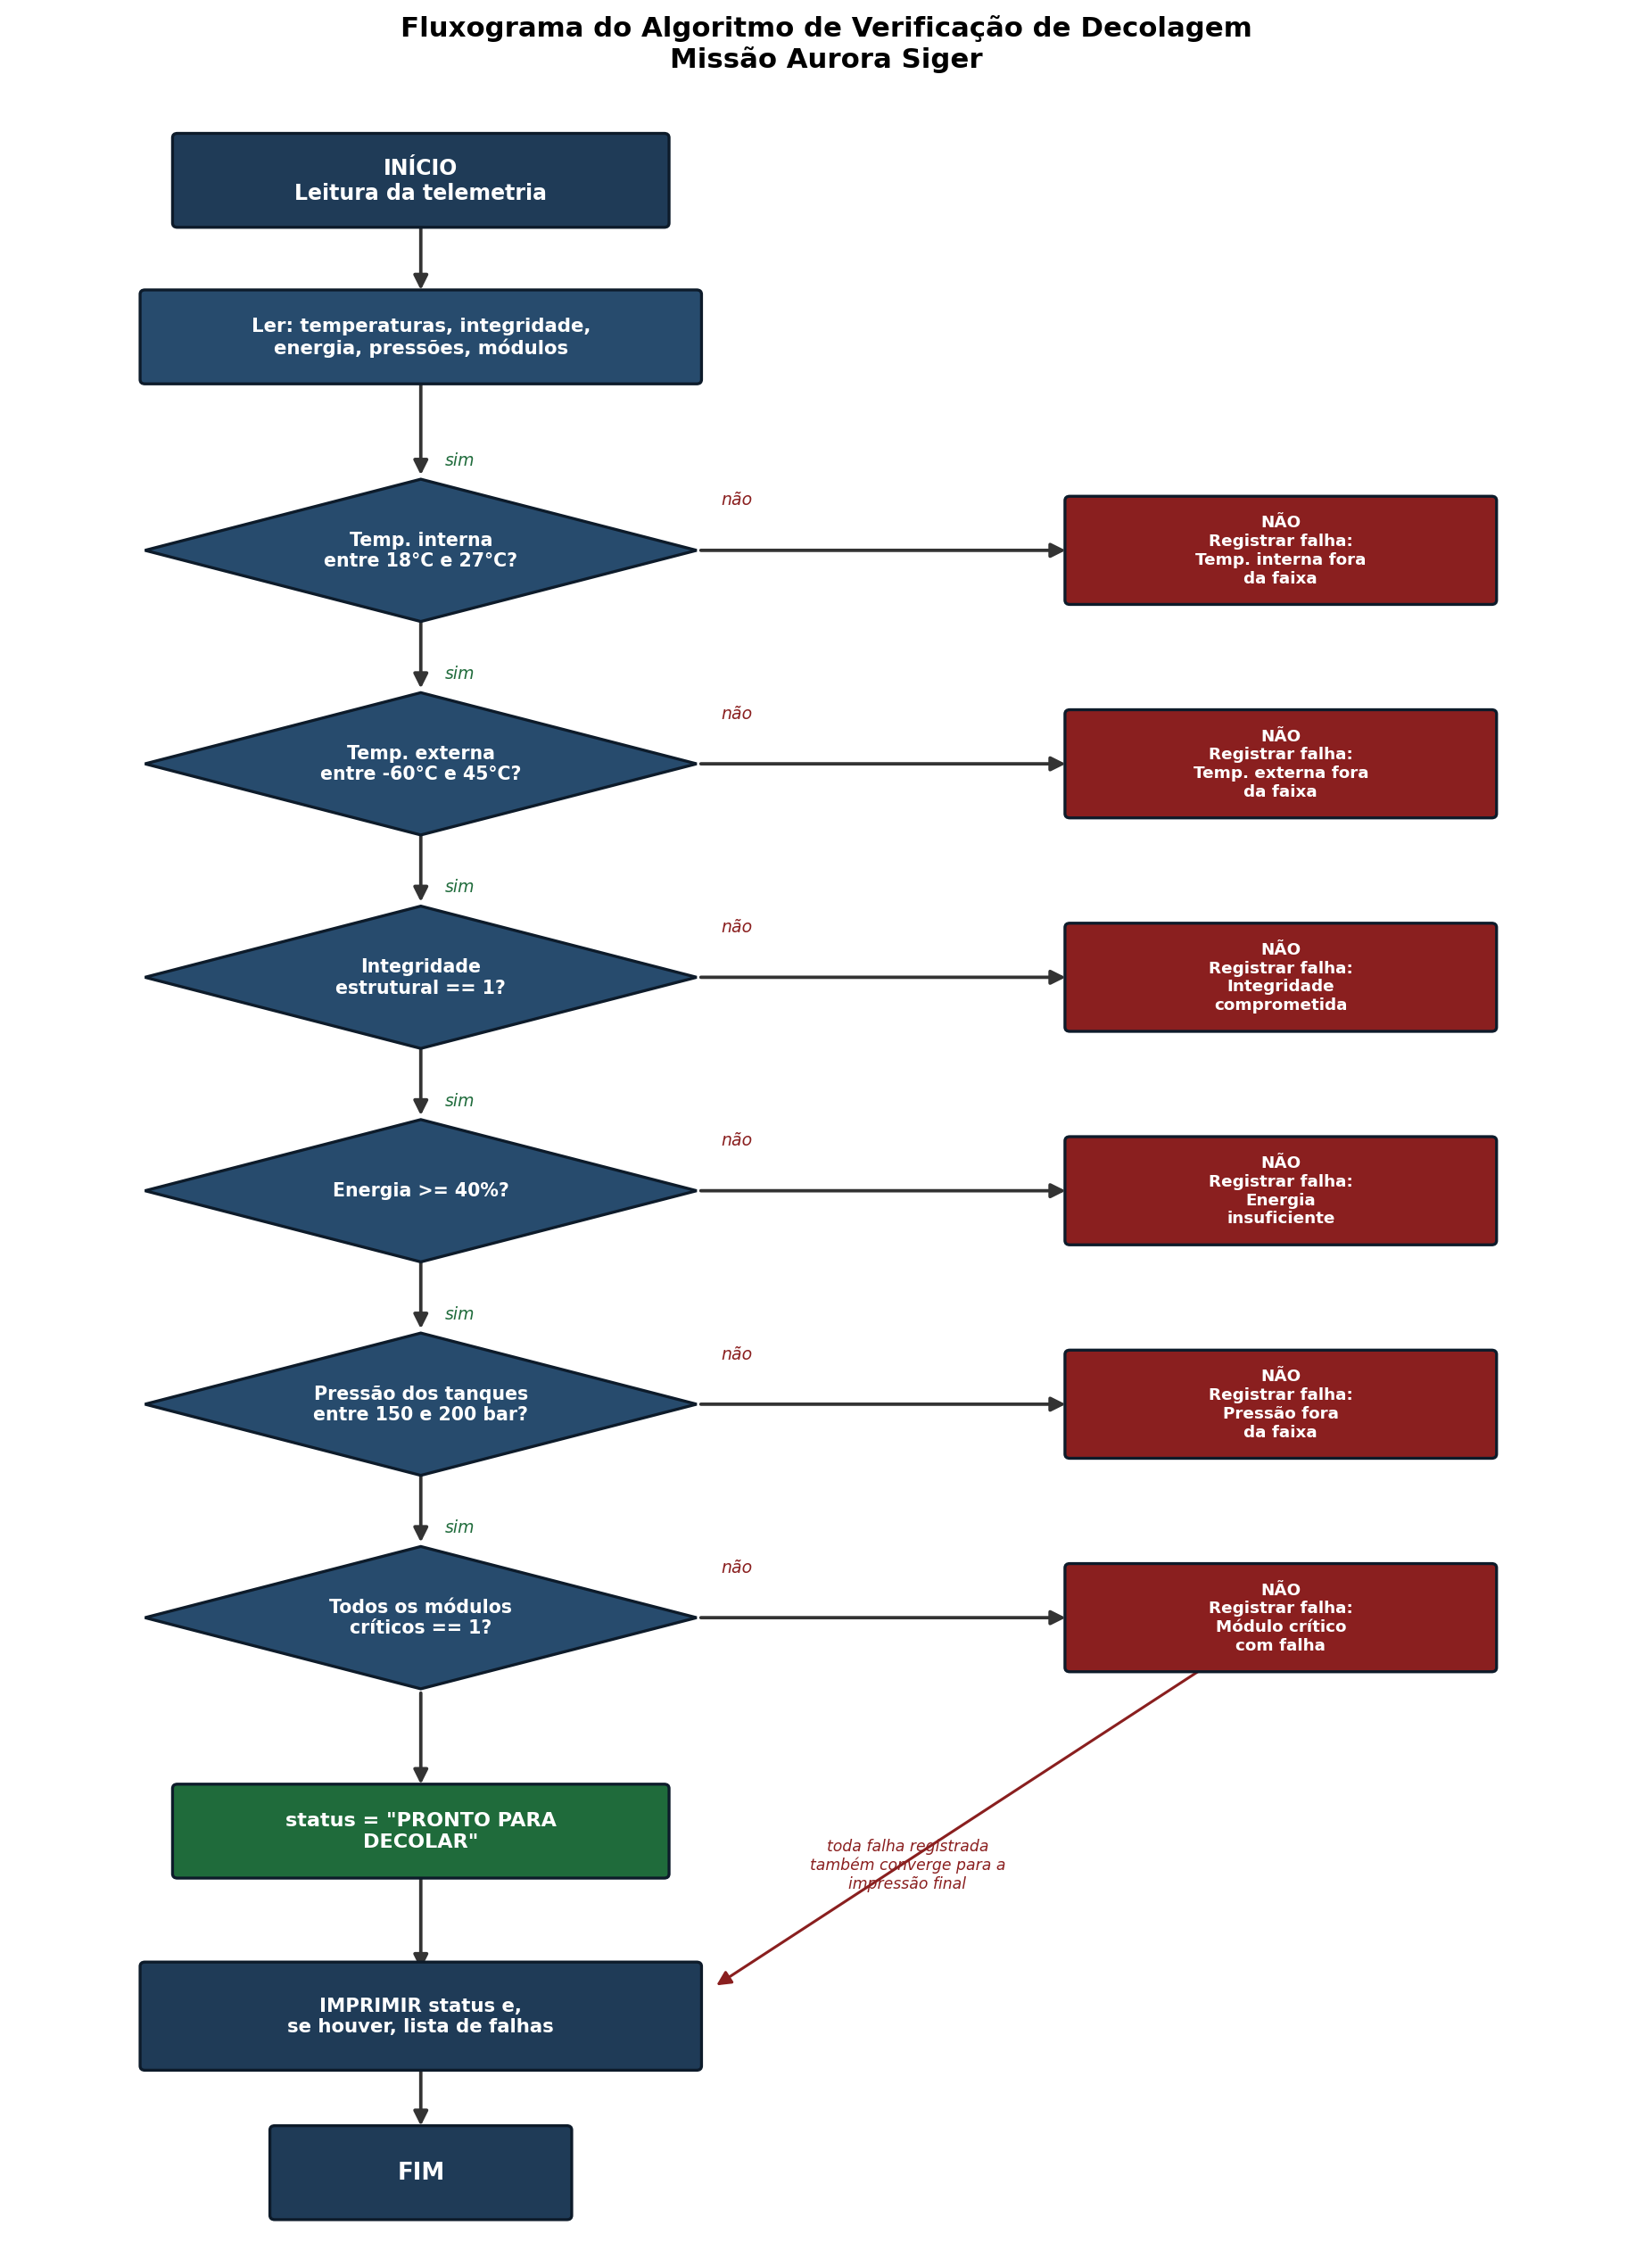

In [3]:
from IPython.display import Image, display
display(Image(filename="imagens/fluxograma_verificacao.png", width=560))

<a id="1.3"></a>
## 1.3 Script em Python

Implementação da lógica do algoritmo acima: leitura dos dados, execução de todas as verificações e impressão do resultado final.

In [4]:
def _dentro_da_faixa(valor, faixa):
    minimo, maximo = faixa
    return minimo <= valor <= maximo


def verificar_decolagem(telemetria):
    """
    Executa todas as verificações da missão e retorna:
    - status: "PRONTO PARA DECOLAR" ou "DECOLAGEM ABORTADA"
    - falhas: lista de strings descrevendo cada não conformidade encontrada
    """
    falhas = []

    t_int = telemetria["temperatura_interna_c"]
    if not _dentro_da_faixa(t_int, FAIXAS_SEGURAS["temperatura_interna_c"]):
        falhas.append(f"Temperatura interna fora da faixa segura: {t_int}°C "
                       f"(esperado {FAIXAS_SEGURAS['temperatura_interna_c']})")

    t_ext = telemetria["temperatura_externa_c"]
    if not _dentro_da_faixa(t_ext, FAIXAS_SEGURAS["temperatura_externa_c"]):
        falhas.append(f"Temperatura externa fora da faixa segura: {t_ext}°C "
                       f"(esperado {FAIXAS_SEGURAS['temperatura_externa_c']})")

    if telemetria["integridade_estrutural"] != 1:
        falhas.append("Integridade estrutural comprometida (sensor reportou 0)")

    energia = telemetria["nivel_energia_pct"]
    if not _dentro_da_faixa(energia, FAIXAS_SEGURAS["nivel_energia_pct"]):
        falhas.append(f"Nível de energia insuficiente: {energia}% "
                       f"(mínimo exigido: {FAIXAS_SEGURAS['nivel_energia_pct'][0]}%)")

    tanques = {
        "oxidante": telemetria["pressao_tanque_oxidante_bar"],
        "combustivel": telemetria["pressao_tanque_combustivel_bar"],
    }
    for nome, pressao in tanques.items():
        if not _dentro_da_faixa(pressao, FAIXAS_SEGURAS["pressao_tanque_bar"]):
            falhas.append(f"Pressão do tanque de {nome} fora da faixa segura: {pressao} bar "
                           f"(esperado {FAIXAS_SEGURAS['pressao_tanque_bar']})")

    for modulo in MODULOS_CRITICOS_ESPERADOS:
        status_modulo = telemetria["modulos_criticos"].get(modulo)
        if status_modulo != 1:
            falhas.append(f"Falha no módulo crítico: '{modulo}' (status={status_modulo})")

    status = "DECOLAGEM ABORTADA" if falhas else "PRONTO PARA DECOLAR"
    return status, falhas


def imprimir_relatorio_verificacao(telemetria):
    """Executa a leitura, verificação e imprime o resultado final."""
    print(f"Timestamp da leitura: {telemetria['timestamp']}")
    print("-" * 55)
    status, falhas = verificar_decolagem(telemetria)

    print(f"RESULTADO: {status}")
    if falhas:
        print("Não conformidades encontradas:")
        for i, f in enumerate(falhas, start=1):
            print(f"  {i}. {f}")
    else:
        print("Todos os parâmetros dentro das faixas seguras. Nave liberada.")
    print("=" * 55)
    return status, falhas

In [5]:
print("### CENÁRIO 1: TELEMETRIA NOMINAL ###\n")
status_nominal, falhas_nominal = imprimir_relatorio_verificacao(gerar_telemetria_nominal())

### CENÁRIO 1: TELEMETRIA NOMINAL ###

Timestamp da leitura: T-00:10:00
-------------------------------------------------------
RESULTADO: PRONTO PARA DECOLAR
Todos os parâmetros dentro das faixas seguras. Nave liberada.


In [6]:
print("### CENÁRIO 2: TELEMETRIA COM FALHAS ###\n")
status_falha, falhas_falha = imprimir_relatorio_verificacao(gerar_telemetria_com_falha())

### CENÁRIO 2: TELEMETRIA COM FALHAS ###

Timestamp da leitura: T-00:10:00
-------------------------------------------------------
RESULTADO: DECOLAGEM ABORTADA
Não conformidades encontradas:
  1. Temperatura interna fora da faixa segura: 29.8°C (esperado (18.0, 27.0))
  2. Nível de energia insuficiente: 33% (mínimo exigido: 40%)
  3. Pressão do tanque de combustivel fora da faixa segura: 141.0 bar (esperado (150.0, 200.0))
  4. Falha no módulo crítico: 'propulsao' (status=0)


<a id="1.4"></a>
## 1.4 Análise energética

A autonomia inicial da nave é calculada a partir de cinco variáveis:

$$E_{disponível} = C_{total} \times \dfrac{Carga\%}{100}$$

$$E_{útil} = E_{disponível} - (E_{disponível} \times \dfrac{Perdas\%}{100})$$

$$E_{pós\text{-}decolagem} = E_{útil} - Consumo_{decolagem}$$

$$Autonomia_{horas} = \dfrac{E_{pós\text{-}decolagem}}{Consumo_{cruzeiro}}$$

Onde:
- **Capacidade total (kWh):** energia máxima armazenável pela bateria principal;
- **Carga atual (%):** valor lido da telemetria (`nivel_energia_pct`);
- **Consumo estimado na decolagem (kWh):** energia gasta pelos sistemas durante a janela de decolagem;
- **Perdas energéticas (%):** perdas por dissipação térmica, conversão DC-DC e ineficiência dos inversores.

In [7]:
def calcular_autonomia(capacidade_total_kwh, carga_atual_pct, consumo_decolagem_kwh,
                        perdas_pct, consumo_medio_cruzeiro_kw):
    """Calcula a autonomia energética da nave após a decolagem."""
    energia_disponivel_kwh = capacidade_total_kwh * (carga_atual_pct / 100)
    perdas_kwh = energia_disponivel_kwh * (perdas_pct / 100)
    energia_util_kwh = energia_disponivel_kwh - perdas_kwh
    energia_pos_decolagem_kwh = energia_util_kwh - consumo_decolagem_kwh
    autonomia_horas = energia_pos_decolagem_kwh / consumo_medio_cruzeiro_kw

    return {
        "capacidade_total_kwh": capacidade_total_kwh,
        "carga_atual_pct": carga_atual_pct,
        "energia_disponivel_kwh": round(energia_disponivel_kwh, 2),
        "perdas_pct": perdas_pct,
        "perdas_kwh": round(perdas_kwh, 2),
        "energia_util_kwh": round(energia_util_kwh, 2),
        "consumo_decolagem_kwh": consumo_decolagem_kwh,
        "energia_pos_decolagem_kwh": round(energia_pos_decolagem_kwh, 2),
        "consumo_medio_cruzeiro_kw": consumo_medio_cruzeiro_kw,
        "autonomia_horas": round(autonomia_horas, 2),
    }


def imprimir_analise_energetica(resultado):
    print("ANÁLISE ENERGÉTICA - AUTONOMIA INICIAL DA NAVE AURORA SIGER")
    print("-" * 55)
    print(f"Capacidade total da bateria........: {resultado['capacidade_total_kwh']:.1f} kWh")
    print(f"Carga atual (telemetria)............: {resultado['carga_atual_pct']}%")
    print(f"Energia disponível...................: {resultado['energia_disponivel_kwh']:.2f} kWh")
    print(f"Perdas energéticas ({resultado['perdas_pct']}%)................: {resultado['perdas_kwh']:.2f} kWh")
    print(f"Energia útil (após perdas)...........: {resultado['energia_util_kwh']:.2f} kWh")
    print(f"Consumo estimado na decolagem........: {resultado['consumo_decolagem_kwh']:.2f} kWh")
    print(f"Energia restante pós-decolagem........: {resultado['energia_pos_decolagem_kwh']:.2f} kWh")
    print(f"Consumo médio em cruzeiro.............: {resultado['consumo_medio_cruzeiro_kw']:.2f} kW")
    print(f"AUTONOMIA ESTIMADA....................: {resultado['autonomia_horas']:.2f} horas")
    print("=" * 55)

# Valores de engenharia da missão (poderiam vir da telemetria/especificação da nave)
resultado_energia = calcular_autonomia(
    capacidade_total_kwh=150.0,
    carga_atual_pct=telemetria_nominal["nivel_energia_pct"],
    consumo_decolagem_kwh=42.0,
    perdas_pct=6,
    consumo_medio_cruzeiro_kw=3.2,
)
imprimir_analise_energetica(resultado_energia)

ANÁLISE ENERGÉTICA - AUTONOMIA INICIAL DA NAVE AURORA SIGER
-------------------------------------------------------
Capacidade total da bateria........: 150.0 kWh
Carga atual (telemetria)............: 87%
Energia disponível...................: 130.50 kWh
Perdas energéticas (6%)................: 7.83 kWh
Energia útil (após perdas)...........: 122.67 kWh
Consumo estimado na decolagem........: 42.00 kWh
Energia restante pós-decolagem........: 80.67 kWh
Consumo médio em cruzeiro.............: 3.20 kW
AUTONOMIA ESTIMADA....................: 25.21 horas


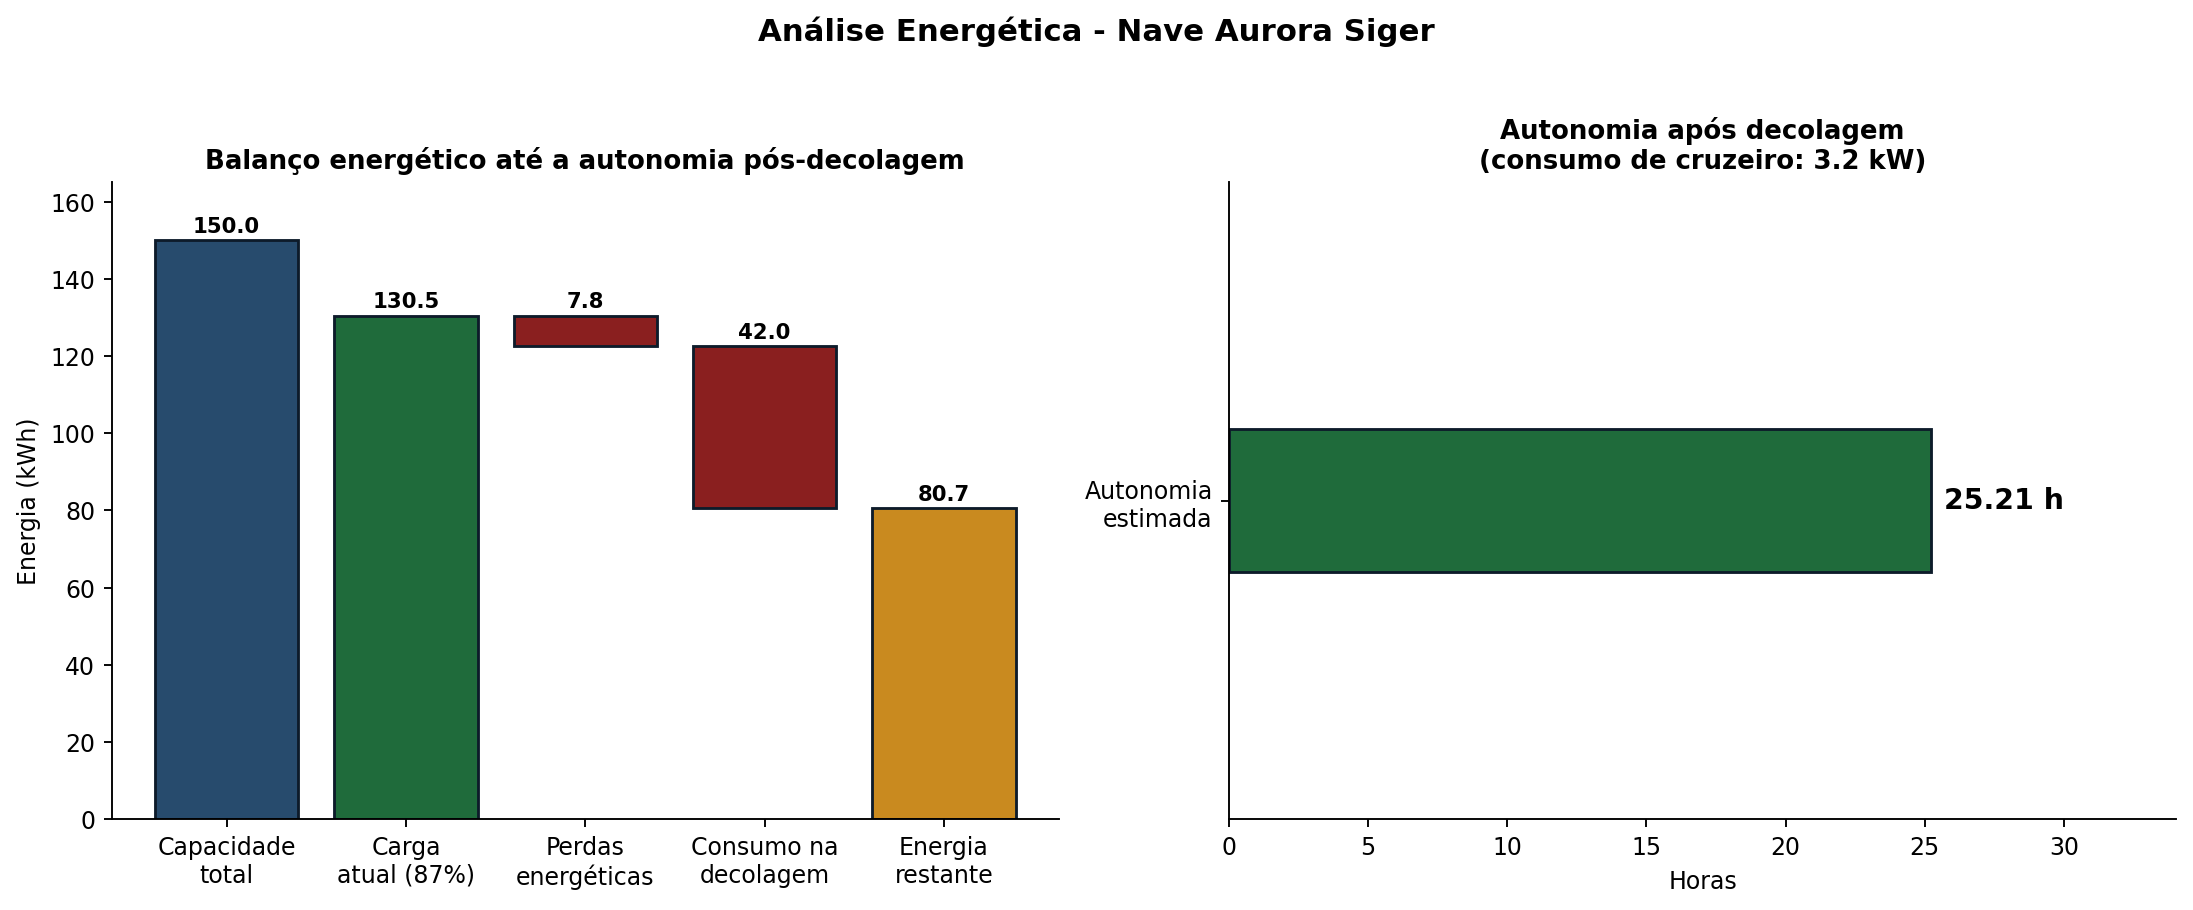

In [8]:
display(Image(filename="imagens/analise_energetica.png", width=760))

**Leitura dos resultados:** com 87% de carga em uma bateria de 150 kWh, a nave dispõe de 130,5 kWh. Após aplicar 6% de perdas energéticas (7,83 kWh) e descontar os 42 kWh consumidos na janela de decolagem, restam 80,67 kWh — suficientes para cerca de **25,21 horas** de operação em regime de cruzeiro (3,2 kW médios). Esse valor informa a equipe de missão sobre a janela de segurança disponível antes de ser necessário acionar fontes de recarga (painéis solares) ou modo de economia de energia.

<a id="1.5"></a>
## 1.5 Análise assistida por IA

Nesta etapa, a telemetria dos dois cenários foi submetida a uma IA (assistente de linguagem) com o seguinte prompt:

> *"Classifique cada parâmetro de telemetria como NOMINAL, ATENÇÃO ou CRÍTICO em relação às faixas seguras informadas, aponte quaisquer anomalias entre os parâmetros (não apenas violações isoladas de faixa) e sugira o nível de risco geral da decolagem com uma recomendação objetiva."*

**Resposta da IA — Cenário 1 (telemetria nominal):**

| Parâmetro | Valor | Classificação |
|---|---|---|
| Temperatura interna | 21,5 °C | 🟢 NOMINAL |
| Temperatura externa | -42,3 °C | 🟢 NOMINAL |
| Integridade estrutural | 1 | 🟢 NOMINAL |
| Nível de energia | 87% | 🟢 NOMINAL (margem confortável acima do mínimo de 40%) |
| Pressão tanque oxidante | 182,0 bar | 🟢 NOMINAL |
| Pressão tanque combustível | 178,5 bar | 🟢 NOMINAL |
| Módulos críticos | todos = 1 | 🟢 NOMINAL |

*Anomalias identificadas:* nenhuma. Os parâmetros não apresentam apenas conformidade isolada — a diferença de pressão entre os dois tanques (3,5 bar) está dentro da variação esperada entre propelentes, não configurando desbalanceamento.
*Sugestão de risco:* **BAIXO**. Recomenda-se prosseguir com a contagem regressiva.

**Resposta da IA — Cenário 2 (telemetria com falhas):**

| Parâmetro | Valor | Classificação |
|---|---|---|
| Temperatura interna | 29,8 °C | 🔴 CRÍTICO (2,8 °C acima do limite de 27 °C) |
| Temperatura externa | -41,0 °C | 🟢 NOMINAL |
| Integridade estrutural | 1 | 🟢 NOMINAL |
| Nível de energia | 33% | 🔴 CRÍTICO (7 p.p. abaixo do mínimo de 40%) |
| Pressão tanque oxidante | 182,0 bar | 🟢 NOMINAL |
| Pressão tanque combustível | 141,0 bar | 🔴 CRÍTICO (9 bar abaixo do mínimo de 150 bar) |
| Módulo "propulsão" | 0 | 🔴 CRÍTICO (módulo inoperante) |

*Anomalias identificadas além das violações de faixa:*
1. **Correlação temperatura × energia:** a temperatura interna elevada combinada à queda de energia sugere possível sobrecarga ou falha em sistema de refrigeração que também consome energia — recomenda-se inspecionar o subsistema térmico antes de nova tentativa.
2. **Desbalanceamento entre tanques:** a diferença de 41 bar entre os tanques de oxidante (182) e combustível (141) é anormalmente alta frente ao padrão observado no cenário nominal (3,5 bar), o que pode indicar vazamento ou falha de pressurização no tanque de combustível — e não apenas uma leitura pontual baixa.
3. **Módulo de propulsão inoperante** é, isoladamente, motivo suficiente para abortar a decolagem, e sua ocorrência simultânea com a queda de pressão do combustível reforça a hipótese de falha relacionada ao sistema de propulsão como um todo.

*Sugestão de risco:* **CRÍTICO / ALTO**. Recomenda-se abortar a decolagem, isolar o subsistema de propulsão e o tanque de combustível para inspeção, e reexecutar a checagem completa antes de nova janela de lançamento.

> 💡 Esta seção documenta o uso da IA como camada de apoio à decisão — ela **não substitui** o algoritmo determinístico do item 1.2/1.3, mas agrega uma leitura qualitativa (padrões e correlações) que regras isoladas de faixa não capturam sozinhas.

<a id="1.6"></a>
## 1.6 Reflexão crítica

**Ética e responsabilidade.** Automatizar a decisão de "PRONTO PARA DECOLAR" ou "DECOLAGEM ABORTADA" transfere para o código uma responsabilidade que, em uma missão real, envolve vidas humanas e recursos de altíssimo valor. Isso exige que as faixas seguras sejam definidas com rigor de engenharia — e não arbitrariamente — e que o sistema seja auditável: qualquer pessoa deve conseguir entender *por que* a nave foi liberada ou abortada, como fizemos ao registrar cada não conformidade individualmente em vez de apenas retornar um "sim/não" opaco. A introdução de IA como camada de apoio (item 1.5) amplia esse cuidado: modelos de linguagem podem identificar padrões úteis, mas também podem "alucinar" conclusões, de modo que suas sugestões devem ser tratadas como apoio à decisão humana e nunca como autoridade final substituindo a verificação determinística.

**Impacto social da exploração espacial.** Missões como a Aurora Siger dependem de investimentos massivos em ciência, engenharia e formação de pessoal altamente especializado. Isso levanta uma tensão legítima: os recursos aplicados na corrida espacial poderiam, em parte, ser direcionados a problemas terrestres imediatos, como saneamento, saúde e educação. Ao mesmo tempo, tecnologias derivadas da exploração espacial — sensores miniaturizados, sistemas de purificação de água, materiais mais leves e resistentes, algoritmos de tomada de decisão autônoma — historicamente retornam à sociedia em aplicações civis. O desafio ético é garantir que os benefícios dessa tecnologia sejam distribuídos de forma ampla, e não apenas apropriados por poucas empresas ou nações, evitando aprofundar desigualdades já existentes no acesso à tecnologia.

**Sustentabilidade tecnológica.** A análise energética do item 1.4 evidencia, em escala reduzida, um princípio maior: qualquer sistema computacional embarcado — seja em uma nave espacial, seja em um data center na Terra — opera sob restrição de energia finita. Projetar algoritmos e sistemas eficientes deixa de ser apenas uma boa prática de engenharia e passa a ser uma responsabilidade ambiental, pois cada joule economizado em processamento é um joule que não precisa ser gerado, transmitido ou armazenado com perdas adicionais. Extrapolando esse raciocínio, o desenvolvimento de tecnologias aeroespaciais sustentáveis (energias renováveis embarcadas, reaproveitamento de componentes, redução de resíduos orbitais) deveria ser tratado como pré-requisito de projeto, e não como otimização posterior — um paralelo direto com a necessidade de eficiência energética em qualquer sistema computacional que impacta o planeta.

---
## ✅ Conclusão

Este notebook consolidou, de ponta a ponta, o relatório operacional de pré-decolagem da missão **Aurora Siger**: organização da telemetria, algoritmo de verificação (fluxograma + pseudocódigo), sua implementação funcional em Python testada em dois cenários, o cálculo de autonomia energética, uma análise assistida por IA e uma reflexão crítica sobre os impactos éticos, sociais e ambientais da missão.

**Repositório:** ver `README.md` para instruções de execução.
